# Validation Evaluation

Scores the notebook 06 models against the independent validation set built in
04_a/04_b: `data/annotations/labels_val.csv`.

**One break from strict numeric order:** this notebook needs notebook 06's
trained checkpoints, which run *after* 04_a/04_b in the pipeline (04_a only
builds the sampling plan and needs no trained model). Run 04_c after both
notebook 06 and 04_b have produced their outputs.

Reported per class, on `block == 'core'` only for population-level ("ALL")
numbers — `type_boost` rows are a simple random draw within a shortfall type,
not an unconditional sample of the pool, so they're folded into the
**per-class** figures (more statistical power on the rare classes they exist
for) but kept out of the aggregate ones:

- **classifier accuracy** and **error rate** — Wilson score interval;
- **false-positive rate** and **false-negative rate** — Wilson;
- **segmentation IoU** — mean with a Student-$t$ interval;
- **ΔE CIE 2000** vs ground truth — mean and median with a $t$ interval, plus the
  ≤2.3 / 2.3–5 / >5 tier table from notebook 06.

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats
from skimage.color import rgb2lab

import torch
import torch.nn as nn
from torchvision import models, transforms
import segmentation_models_pytorch as smp
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

# colormath needs a numpy attribute removed in newer numpy — restore it before import
if not hasattr(np, 'asscalar'):
    np.asscalar = lambda a: a.item()
from colormath.color_objects import LabColor
from colormath.color_diff import delta_e_cie2000

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = ('mps' if torch.backends.mps.is_available()
          else 'cuda' if torch.cuda.is_available()
          else 'cpu')

BASE       = os.path.abspath('../data')
ANN_DIR    = os.path.join(BASE, 'annotations')
CLEAN      = os.path.join(BASE, 'img', 'original_clean')
MODELS_DIR = os.path.abspath('../models')

print(f'device: {DEVICE}')


def find_image(img_name, img_dirs=(CLEAN,)):
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None

device: mps


In [2]:
labels_val_df = pd.read_csv(os.path.join(ANN_DIR, 'labels_val.csv'))
print(f'labels_val.csv: {len(labels_val_df)} rows, blocks: '
      f'{labels_val_df["block"].value_counts().to_dict()}')

labels_val.csv: 480 rows, blocks: {'core': 348, 'type_boost': 132}


In [3]:
# Classifier — class order comes from the checkpoint, never hardcoded (CLAUDE.md)
IMG_SIZE_CLS = 224
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def build_classifier(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


def score_clf_uncertainty(model, img_path, device, class_names):
    """Return (predicted_class, confidence, full_softmax_probs). From notebook 06."""
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(model(val_tf(img).unsqueeze(0).to(device)), dim=1).squeeze().cpu().numpy()
    return class_names[int(probs.argmax())], float(probs.max()), probs


CLF_THRESHOLD = 0.6
_ckpt = torch.load(os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth'), map_location=DEVICE)
classes = list(_ckpt['classes'])
assert classes == sorted(classes) and len(classes) == 7, classes

clf = build_classifier(len(classes)).to(DEVICE)
clf.load_state_dict(_ckpt['model_state_dict'])
clf.eval()
print(f'classifier loaded — classes: {classes}')

classifier loaded — classes: ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch', 'unclassifiable']


In [4]:
IMG_SIZE_SEG = 256
seg_img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
SEG_CLASSES = {'bullet', 'liquid', 'pencil'}


def build_segmenter():
    return smp.Unet(encoder_name='resnet18', encoder_weights=None, in_channels=3, classes=1)


def load_seg(fname):
    m = build_segmenter().to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(MODELS_DIR, fname), map_location=DEVICE)['model_state_dict'])
    return m.eval()


seg = load_seg('unet_segmenter.pth')
seg_other = load_seg('unet_segmenter_other.pth')
seg_swatch = load_seg('unet_swatch.pth')
seg_lips = load_seg('unet_lips.pth')


def predict_mask(model, img_path, device, threshold=0.5):
    img = Image.open(img_path).convert('RGB')
    ow, oh = img.size
    x = seg_img_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
    m = (prob > threshold).astype(np.uint8)
    return np.array(Image.fromarray(m * 255).resize((ow, oh), Image.NEAREST)) // 255


def extract_masked_color(img_rgb, mask_arr):
    lab = rgb2lab(img_rgb / 255.0)
    px = lab[mask_arr == 1]
    return np.array([np.nan] * 3) if len(px) == 0 else np.median(px, axis=0)


def extract_dominant_cluster_color(img_rgb, mask_arr, k=3):
    lab = rgb2lab(img_rgb / 255.0)
    px = lab[mask_arr == 1]
    if len(px) == 0:
        return np.full(3, np.nan)
    if len(px) < k:
        return np.median(px, axis=0)
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto').fit(px)
    return km.cluster_centers_[np.bincount(km.labels_).argmax()]


def delta_e(pred_lab, true_lab):
    return float(delta_e_cie2000(LabColor(*pred_lab), LabColor(*true_lab)))


def batch_iou(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union else np.nan


def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan, np.nan)
    phat = k / n
    denom = 1 + z ** 2 / n
    centre = (phat + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z ** 2 / (4 * n ** 2)) / denom
    return phat, centre - half, centre + half


def mean_ci(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return (np.nan, np.nan, np.nan)
    m = x.mean()
    h = stats.t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))
    return m, m - h, m + h


print('segmenters loaded — ready to evaluate')

segmenters loaded — ready to evaluate


In [5]:
def route_and_extract(img_path, route_label):
    img = np.array(Image.open(img_path).convert('RGB'))
    if route_label == 'swatch':
        mask = predict_mask(seg_swatch, img_path, DEVICE); lab = extract_masked_color(img, mask)
    elif route_label in SEG_CLASSES:
        mask = predict_mask(seg, img_path, DEVICE); lab = extract_masked_color(img, mask)
    elif route_label == 'closed':
        mask = predict_mask(seg_other, img_path, DEVICE); lab = extract_dominant_cluster_color(img, mask)
    elif route_label == 'lips':
        mask = predict_mask(seg_lips, img_path, DEVICE); lab = extract_masked_color(img, mask)
    else:
        mask, lab = None, np.full(3, np.nan)
    return mask, lab


def evaluate(labels_df):
    recs = []
    for _, row in labels_df.iterrows():
        ip = find_image(row['img_name_disk'])
        if ip is None:
            continue
        pred_label, conf, _ = score_clf_uncertainty(clf, ip, DEVICE, classes)
        routed = pred_label if conf >= CLF_THRESHOLD else 'unclassifiable'
        _, lab_pred = route_and_extract(ip, routed)
        _, lab_gt = route_and_extract(ip, row['label'])  # GT-routed: isolates segmenter quality

        iou = np.nan
        mp = row.get('mask_path')
        if isinstance(mp, str) and os.path.exists(mp) and row['label'] != 'unclassifiable':
            gt_mask = (np.array(Image.open(mp).convert('L')) > 127).astype(np.uint8)
            pr_mask = predict_mask(
                seg_swatch if row['label'] == 'swatch' else
                seg if row['label'] in SEG_CLASSES else
                seg_other if row['label'] == 'closed' else
                seg_lips, ip, DEVICE)
            if pr_mask.shape != gt_mask.shape:
                pr_mask = np.array(Image.fromarray(pr_mask * 255).resize(
                    gt_mask.shape[::-1], Image.NEAREST)) // 255
            iou = batch_iou(pr_mask, gt_mask)

        de_pred = de_gt = np.nan
        if pd.notna(row.get('true_L')):
            tl = [row['true_L'], row['true_a'], row['true_b']]
            if not np.isnan(lab_pred).any():
                de_pred = delta_e(lab_pred, tl)
            if not np.isnan(lab_gt).any():
                de_gt = delta_e(lab_gt, tl)

        recs.append({
            'img_name_disk': row['img_name_disk'], 'block': row['block'],
            'true_label': row['label'], 'pred_label': pred_label, 'confidence': conf,
            'routed_label': routed, 'routed_correct': routed == row['label'],
            'iou': iou, 'delta_e_pred_routed': de_pred, 'delta_e_gt_routed': de_gt,
        })
    return pd.DataFrame(recs)


val_eval = evaluate(labels_val_df)
_bc = val_eval['block'].value_counts().to_dict()
print(f'evaluated {len(val_eval)} validation images — blocks: {_bc}')

evaluated 480 validation images — blocks: {'core': 348, 'type_boost': 132}


CLASSIFIER — per class (core + type_boost)

                n_true  n_pred  accuracy      acc_95ci  fn_rate       fn_95ci  fp_rate       fp_95ci
class                                                                                               
bullet             127     147     0.961  [0.91, 0.98]    0.039  [0.02, 0.09]    0.170  [0.12, 0.24]
closed              12      18     0.583  [0.32, 0.81]    0.417  [0.19, 0.68]    0.611  [0.39, 0.80]
lips                11      14     1.000  [0.74, 1.00]    0.000  [0.00, 0.26]    0.214  [0.08, 0.48]
liquid             104     112     0.923  [0.86, 0.96]    0.077  [0.04, 0.14]    0.143  [0.09, 0.22]
pencil              24      19     0.708  [0.51, 0.85]    0.292  [0.15, 0.49]    0.105  [0.03, 0.31]
swatch             169     151     0.876  [0.82, 0.92]    0.124  [0.08, 0.18]    0.020  [0.01, 0.06]
unclassifiable      33      19     0.394  [0.25, 0.56]    0.606  [0.44, 0.75]    0.316  [0.15, 0.54]

classification_report (core only — population-

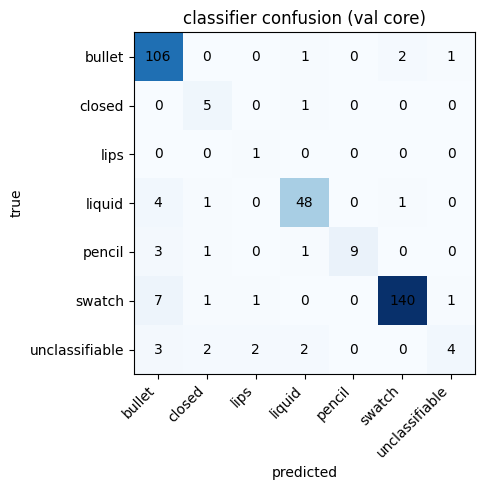

In [6]:
# Population-level ("ALL") numbers use core only — type_boost is not an
# unconditional sample of the pool. Per-class numbers use every row: it isn't
# confidence-ranked or model-derived, so combining them just adds statistical
# power on the classes it exists to shore up.
core = val_eval[val_eval['block'] == 'core']
all_rows = val_eval

rows = []
for c in classes:
    tc = all_rows[all_rows['true_label'] == c]
    pc = all_rows[all_rows['pred_label'] == c]
    acc_p, acc_lo, acc_hi = wilson((tc['pred_label'] == c).sum(), len(tc))
    fn_p, fn_lo, fn_hi = wilson((tc['pred_label'] != c).sum(), len(tc))
    fp_p, fp_lo, fp_hi = wilson((pc['true_label'] != c).sum(), len(pc))
    rows.append({
        'class': c, 'n_true': len(tc), 'n_pred': len(pc),
        'accuracy': acc_p, 'acc_95ci': f'[{acc_lo:.2f}, {acc_hi:.2f}]',
        'fn_rate': fn_p, 'fn_95ci': f'[{fn_lo:.2f}, {fn_hi:.2f}]',
        'fp_rate': fp_p, 'fp_95ci': f'[{fp_lo:.2f}, {fp_hi:.2f}]',
    })
clf_metrics = pd.DataFrame(rows).set_index('class')
print('CLASSIFIER — per class (core + type_boost)\n')
print(clf_metrics.to_string(float_format=lambda x: f'{x:.3f}'))

print('\nclassification_report (core only — population-level mix):')
print(classification_report(core['true_label'], core['pred_label'],
                            labels=classes, target_names=classes, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(core['true_label'], core['pred_label'], labels=classes)
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
for (r, cc), v in np.ndenumerate(cm):
    ax.text(cc, r, v, ha='center', va='center')
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('classifier confusion (val core)')
plt.tight_layout(); plt.show()

SEGMENTATION IoU — GT-routed, per type (core + type_boost)

  swatch   n=169   IoU 0.886  95% CI [0.863, 0.908]
  bullet   n=127   IoU 0.778  95% CI [0.743, 0.814]
  liquid   n=104   IoU 0.606  95% CI [0.560, 0.652]
  pencil   n= 24   IoU 0.487  95% CI [0.369, 0.605]
  closed   n= 12   IoU 0.621  95% CI [0.512, 0.731]
  ALL (core)   n=335   IoU 0.798  95% CI [0.775, 0.821]

ΔE CIE 2000 vs ground truth — predicted-routed, per type

  swatch   n=149   mean 0.60 [-0.03, 1.22]   median 0.07
  bullet   n=117   mean 1.01 [0.53, 1.49]   median 0.42
  liquid   n= 97   mean 2.71 [1.64, 3.77]   median 1.23
  pencil   n= 20   mean 1.89 [0.24, 3.53]   median 0.45
  closed   n=  6   mean 2.39 [0.55, 4.23]   median 1.68
  lips     n= 11   mean 1.58 [0.14, 3.02]   median 0.78
  ALL (core)   n=311   mean 0.96 [0.62, 1.31]   median 0.26

ΔE tier breakdown (predicted-routed, core only):
delta_e_pred_routed
<= 2.3 (great)    90.4
2.3-5 (ok)         6.8
> 5 (poor)         2.9


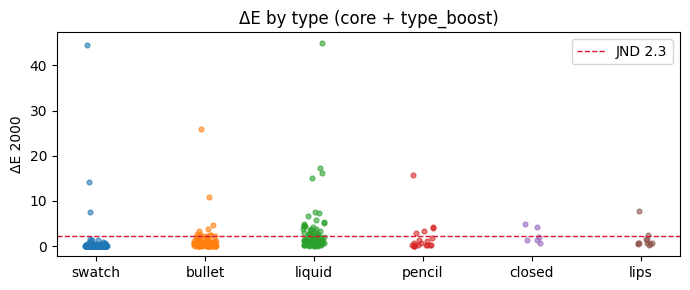

In [7]:
print('SEGMENTATION IoU — GT-routed, per type (core + type_boost)\n')
for c in ['swatch', 'bullet', 'liquid', 'pencil', 'closed']:
    m, lo, hi = mean_ci(all_rows.loc[all_rows['true_label'] == c, 'iou'])
    n = all_rows.loc[all_rows['true_label'] == c, 'iou'].notna().sum()
    print(f'  {c:8s} n={n:3d}   IoU {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')
m, lo, hi = mean_ci(core['iou'])
print(f'  {"ALL (core)":12s} n={core["iou"].notna().sum():3d}   IoU {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

print('\nΔE CIE 2000 vs ground truth — predicted-routed, per type\n')
for c in ['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips']:
    d = all_rows.loc[all_rows['true_label'] == c, 'delta_e_pred_routed']
    m, lo, hi = mean_ci(d)
    md_ = d.dropna().median()
    print(f'  {c:8s} n={d.notna().sum():3d}   mean {m:.2f} [{lo:.2f}, {hi:.2f}]   median {md_:.2f}')
d = core['delta_e_pred_routed']
m, lo, hi = mean_ci(d)
print(f'  {"ALL (core)":12s} n={d.notna().sum():3d}   mean {m:.2f} [{lo:.2f}, {hi:.2f}]   median {d.dropna().median():.2f}')

print('\nΔE tier breakdown (predicted-routed, core only):')
tier = pd.cut(core['delta_e_pred_routed'].dropna(), [-0.1, 2.3, 5, 1e9],
              labels=['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)'])
print((tier.value_counts(normalize=True).reindex(['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)']) * 100).round(1).to_string())

d = all_rows['delta_e_pred_routed'].dropna()
if len(d):
    fig, ax = plt.subplots(figsize=(7, 3))
    for i, c in enumerate(['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips']):
        y = all_rows.loc[all_rows['true_label'] == c, 'delta_e_pred_routed'].dropna()
        ax.scatter(np.full(len(y), i) + np.random.uniform(-0.1, 0.1, len(y)), y, s=12, alpha=0.6)
    ax.axhline(2.3, color='crimson', ls='--', lw=1, label='JND 2.3')
    ax.set_xticks(range(6)); ax.set_xticklabels(['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips'])
    ax.set_ylabel('ΔE 2000'); ax.legend(); ax.set_title('ΔE by type (core + type_boost)')
    plt.tight_layout(); plt.show()

### Results narrative (fill after the annotation round)

> On the independent validation set (core block, _N_ = `{}`), the notebook-06
> classifier reached _`{}`%_ overall accuracy (95% CI `{}`). Per-class accuracy was
> lowest for `{}` (`{}`, CI `{}`), consistent with its thin training support.
> GT-routed segmentation IoU was `{}` overall; predicted-routed ΔE CIE 2000 had a
> median of `{}` and `{}`% of images within the 2.3 JND threshold.

Compare each figure against notebook 06's development-set values — expect the
independent estimates to be somewhat worse, with wider intervals.

## How to run

```bash
.venv/bin/python -m jupyter nbconvert --to notebook --execute --inplace \
  notebooks/04_c_validation_evaluation.ipynb
```

Requires notebook 06's checkpoints in `models/` and `data/annotations/labels_val.csv`
from 04_b. Writes no files — prints metrics and displays plots in the notebook.